En esta notebook vamos a trabajar el problema de clasificación multi-label de artículos científicos en función de su título y tu abstract.

In [8]:
%matplotlib inline

En primera instancia, se obtienen los datos del dataset multilabel_scientific_articles.csv

In [9]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

data = pd.read_csv('multilabel_scientific_articles.csv')

data.head(20)

,ID,TITLE,ABSTRACT,Computer Science,Physics,Mathematics,Statistics,Quantitative Biology,Quantitative Finance
0,1,Reconstructing Subject-Specific Effect Maps,Predictive models allow subject-specific inf...,1.0,0.0,0.0,0.0,0.0,0.0
1,2,Rotation Invariance Neural Network,Rotation invariance and translation invarian...,1.0,0.0,0.0,0.0,0.0,0.0
2,3,Spherical polyharmonics and Poisson kernels fo...,We introduce and develop the notion of spher...,0.0,0.0,1.0,0.0,0.0,0.0
3,4,A finite element approximation for the stochas...,The stochastic Landau--Lifshitz--Gilbert (LL...,0.0,0.0,1.0,0.0,0.0,0.0
4,5,Comparative study of Discrete Wavelet Transfor...,Fourier-transform infra-red (FTIR) spectra o...,1.0,0.0,0.0,1.0,0.0,0.0
5,6,On maximizing the fundamental frequency of the...,Let $\Omega \subset \mathbb{R}^n$ be a bound...,0.0,0.0,1.0,0.0,0.0,0.0
6,7,On the rotation period and shape of the hyperb...,We observed the newly discovered hyperbolic ...,0.0,1.0,0.0,0.0,0.0,0.0
7,8,Adverse effects of polymer coating on heat tra...,The ability of metallic nanoparticles to sup...,0.0,1.0,0.0,0.0,0.0,0.0
8,9,SPH calculations of Mars-scale collisions: the...,We model large-scale ($\approx$2000km) impac...,0.0,1.0,0.0,0.0,0.0,0.0
9,10,$\mathcal{R}_{0}$ fails to predict the outbrea...,Time varying susceptibility of host at indiv...,0.0,0.0,0.0,0.0,1.0,0.0


Obtenemos un reporte de los datos

In [3]:
from ydata_profiling import ProfileReport


profile = ProfileReport(data, title="Reporte Exploratorio", explorative=True)
profile

C:\Users\agust\AppData\Local\Temp\ipykernel_20004\339549371.py:1: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 9/9 [00:04<00:00,  1.85it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Eliminamos los registros faltantes

In [10]:
data = data.dropna()
data.describe()

,ID,Computer Science,Physics,Mathematics,Statistics,Quantitative Biology,Quantitative Finance
count,20972.000000,20972.000000,20972.000000,20972.000000,20972.000000,20972.000000,20972.000000
mean,10486.500000,0.409784,0.286716,0.267881,0.248236,0.027990,0.011873
std,6054.239259,0.491806,0.452238,0.442866,0.432000,0.164947,0.108317
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5243.750000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,10486.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,15729.250000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
max,20972.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Nos quedamos con aquellos registros donde hay clasificación multilabel.

In [11]:
cats = pd.DataFrame(data[data.columns[-6:]].sum(axis=1))
data = data[data.index.isin(cats[cats[0] > 1].index)]
data.head()

,ID,TITLE,ABSTRACT,Computer Science,Physics,Mathematics,Statistics,Quantitative Biology,Quantitative Finance
4,5,Comparative study of Discrete Wavelet Transfor...,Fourier-transform infra-red (FTIR) spectra o...,1.0,0.0,0.0,1.0,0.0,0.0
21,22,Many-Body Localization: Stability and Instability,Rare regions with weak disorder (Griffiths r...,0.0,1.0,1.0,0.0,0.0,0.0
28,29,Minimax Estimation of the $L_1$ Distance,We consider the problem of estimating the $L...,0.0,0.0,1.0,1.0,0.0,0.0
29,30,Density large deviations for multidimensional ...,We investigate the density large deviation f...,0.0,1.0,1.0,0.0,0.0,0.0
30,31,mixup: Beyond Empirical Risk Minimization,"Large deep neural networks are powerful, but...",1.0,0.0,0.0,1.0,0.0,0.0


Hacemos un barplot para tener una idea de la cantidad de datos etiquetados por cada categoría.

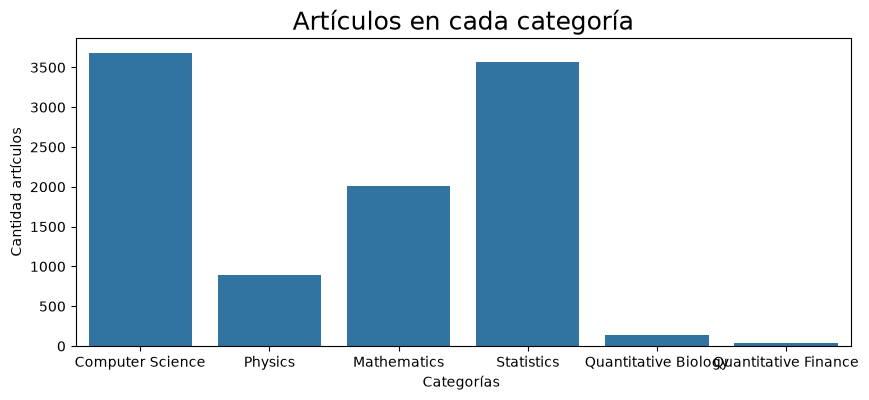

In [12]:
plt.figure(figsize=(10,4))

all_columns = list(data.columns.values)
categories = all_columns[-6:]

ax = sns.barplot(data[data.columns[-6:]].sum())

plt.title("Artículos en cada categoría", fontsize=18)
plt.ylabel('Cantidad artículos', fontsize=10)
plt.xlabel('Categorías ', fontsize=10)
plt.show()

En lo que sigue, hacemos una partición de los datos. El 70 % de los datos para entrenamiento y el restante 30 % para el testeo de los modelos. En particular, nos interesa quedarnos con los títulos.

In [13]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(data, random_state=42, test_size=0.30, shuffle=True)

X_train = train['TITLE']
X_test = test['TITLE']

y_train = train.iloc[:,-6:]
y_test = test.iloc[:,-6:]

En lo que sigue, definimos un pipeline para entrenar y obtener una representación TF-IDF de los textos. Asimismo, se entrena un modelo de Logistic Regression para clasificar los textos y resolver el problema multilabel y multiclase utilizando una estrategia one vs rest.

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.multiclass import OneVsRestClassifier

clf = Pipeline([
                ('vectorizador', TfidfVectorizer()), 
                ('onevsrest', OneVsRestClassifier(LogisticRegression(solver='sag'), n_jobs=-1)),
            ])

clf.fit(X_train, y_train)
prediction = clf.predict(X_test)


En las siguientes lineas, se evalúa el desempeño del modelo en base a diferentes métricas.

In [15]:
from sklearn.metrics import hamming_loss
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score

averages = [None, 'micro', 'macro', 'weighted', 'samples']

print('Subset Accuracy {}'.format(accuracy_score(y_test, prediction)))
print('Hamming Loss {}'.format(hamming_loss(y_test, prediction)))

for avg in averages:
    print('-----------------',avg)
    print('Precision {}'.format(precision_score(y_test, prediction,average=avg)))
    print('Recall {}'.format(recall_score(y_test, prediction,average=avg)))
    print('F1 {}'.format(f1_score(y_test, prediction,average=avg)))    
    print('')

Subset Accuracy 0.5422721268163805
Hamming Loss 0.1306693086745927
----------------- None
Precision [0.80060423 0.82926829 0.75274725 0.82329945 0.         0.        ]
Recall [0.96101541 0.13076923 0.67821782 0.96694215 0.         0.        ]
F1 [0.87350639 0.22591362 0.71354167 0.88935811 0.         0.        ]

----------------- micro
Precision 0.8018808777429467
Recall 0.8217153870864118
F1 0.8116769792162463

----------------- macro
Precision 0.5343198712891417
Recall 0.45615743563717875
F1 0.4503866304204343

----------------- weighted
Precision 0.7874764408951763
Recall 0.8217153870864118
F1 0.778391363813471

----------------- samples
Precision 0.8145090268604138
Recall 0.8250770585645091
F1 0.8105460149713781



c:\Users\agust\anaconda3\envs\datascience\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\agust\anaconda3\envs\datascience\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\agust\anaconda3\envs\datascience\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()}

Se hace una simple prueba del desempeño del modelo

In [16]:
categories = data.columns[-6:]
pred = clf.predict(["the quantitative finance"])[0]
predicted_categories = categories[pred == 1]
print(predicted_categories)

Index(['Computer Science', 'Statistics'], dtype='object')


**Vamos a realizar otro tipo de preprocesamiento para entrenar los modelos.** 

Vamos a utilizar los abstracts, vamos a borrarles los simbolos y caracteres especiales, vamos a realizar stemmer, lemmatización y luego de esto, vamos a utilizar representación vectorial para analizar los abstracts. Eso mismo, le vamos a pasar a los modelos y veremos como se clasifica utilizando la representación text2vect o alguna similar

In [17]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(data, random_state=42, test_size=0.25, shuffle=True)

X_train = train['ABSTRACT']
X_test = test['ABSTRACT']

y_train = train.iloc[:,-6:]
y_test = test.iloc[:,-6:]

Teniendo en cuenta que vamos a procesar abstracts de artículos científicos, los cuales tienen mucha terminología y notación particular, vamos a utilizar un preprocesamiento diferente de los textos. En particular, vamos a definir una clase Preprocesador, en la cual se eliminan las stopwords, se eliminan los caracteres especiales, se utiliza casefold, se hace tokenización y lematización utilizando spacy. Asimismo, el preprocesador, procesa el texto y devuelve la representación vectorial dada por Spacy.

In [18]:
from sklearn.pipeline import Pipeline
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.base import BaseEstimator, TransformerMixin
import re
import spacy

nlp = spacy.load("en_core_web_lg")


class Preprocesador(BaseEstimator, TransformerMixin):

    def __init__(self, remove_digits=False):
        self.remove_digits = remove_digits

    def remove_special_chars(self, text):
        text = text.casefold()
        pattern = r'[^a-zA-Z0-9\s]' if not self.remove_digits else r'[^a-zA-Z\s]'
        text = re.sub(pattern, '', text)
        return text
    


    def fit(self, X, y=None):
        return self

    def transform(self, X):   
        vectores = []
        for text in X:
            text = self.remove_special_chars(text)
            doc = nlp(text)
            tokens = [
                token.lemma_
                for token in doc
                if not token.is_stop and not token.is_punct
            ]
            texto_limpio = " ".join(tokens)
            doc_limpio = nlp(texto_limpio)
            vectores.append(doc_limpio.vector)
        return vectores 

clf = Pipeline([
    ('transformar_texto', Preprocesador()),
    ('onevsrest', OneVsRestClassifier(
        LogisticRegression(solver='sag'),
        n_jobs=-1
    ))
])


clf.fit(X_train, y_train)

y_hat = clf.predict(X_test)

Evaluamos el desempeño del modelo con las mismas métricas que hemos utilizado anteriormente.

In [20]:
averages = [None, 'micro', 'macro', 'weighted', 'samples']

print('Subset Accuracy {}'.format(accuracy_score(y_test, y_hat)))
print('Hamming Loss {}'.format(hamming_loss(y_test, y_hat)))

for avg in averages:
    print('-----------------',avg)
    print('Precision {}'.format(precision_score(y_test, y_hat,average=avg)))
    print('Recall {}'.format(recall_score(y_test, y_hat,average=avg)))
    print('F1 {}'.format(f1_score(y_test, y_hat,average=avg)))    
    print('')

Subset Accuracy 0.5939730372720063
Hamming Loss 0.10322495374041765
----------------- None
Precision [0.87616099 0.78518519 0.81449893 0.86316872 1.         0.        ]
Recall [0.91192266 0.48401826 0.76553106 0.93118757 0.15625    0.        ]
F1 [0.89368421 0.59887006 0.7892562  0.89588895 0.27027027 0.        ]

----------------- micro
Precision 0.8552941176470589
Recall 0.8411106826070189
F1 0.8481431071359129

----------------- macro
Precision 0.7231689723465022
Recall 0.5414849266890273
F1 0.5746616139753824

----------------- weighted
Precision 0.8499079932517108
Recall 0.8411106826070189
F1 0.8379699098863213

----------------- samples
Precision 0.8678297647369811
Recall 0.844964314036479
F1 0.8443298969072165



c:\Users\agust\anaconda3\envs\datascience\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\agust\anaconda3\envs\datascience\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\agust\anaconda3\envs\datascience\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()}

Hacemos una prueba del modelo entrenado

In [21]:
categories = data.columns[-6:]

predicted_categories = clf.predict(["In this article we study the structure of neuronal networks"])[0]

predicted = categories[predicted_categories==1]

print(predicted)

Index(['Computer Science', 'Physics', 'Statistics', 'Quantitative Biology'], dtype='object')
